# Project · Titanic Survival AI
## EDA → Feature Engineering → Feature Selection → Model Comparison → Final Model → Research Report

데이터셋: **Kaggle Titanic** (`train.csv`)  
Target: **Survived** (`0=사망`, `1=생존`)

이 노트북은 승객 정보를 이용하여 생존 여부를 예측하는 **이진 분류(Binary Classification)** 프로젝트입니다.

# Chapter 1. 프로젝트 소개

## Titanic Survival Prediction이란?
1912년 타이타닉호 승객의 객실 등급, 성별, 나이, 운임, 가족관계 등의 정보를 이용해 생존 여부를 예측하는 문제입니다.

### 프로젝트 목표
- Titanic 데이터의 구조와 품질을 점검한다.
- Target인 `Survived`의 분포를 확인한다.
- EDA 결과를 근거로 가설을 수립한다.
- 생존과 관련된 파생변수를 만든다.
- Feature Selection으로 입력 변수를 검증한다.
- Logistic Regression, Decision Tree, Random Forest, XGBoost를 비교한다.
- 최종 모델을 선정하고 저장한다.

# Chapter 2. EDA (Exploratory Data Analysis, 탐색적 데이터 분석)

EDA에서는 다음 질문에 답합니다.
- 데이터는 몇 명의 승객과 몇 개의 컬럼으로 구성되어 있는가?
- 결측치와 중복 데이터가 존재하는가?
- 생존자와 사망자의 비율은 어떠한가?
- 성별, 객실 등급, 나이, 운임, 탑승항구에 따라 생존률이 달라지는가?
- 이상치와 강한 상관관계가 존재하는가?

In [2]:
# ---------------------------------------------------------------
# 라이브러리 불러오기
# ---------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 1. seaborn 그래프 기본 스타일
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.unicode_minus"] = False

# 2. OS별 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux, Colab, Ubuntu
    plt.rcParams["font.family"] = "NanumGothic"

# 3. 기타 Matplotlib 설정
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

pd.set_option("display.max_columns", 100)


In [3]:
# ---------------------------------------------------------------
# 데이터 불러오기
# ---------------------------------------------------------------
df = pd.read_csv('data/train.csv')
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


## 2-1. Shape 확인

In [4]:
print("데이터 Shape:", df.shape)
print(f"승객 수: {df.shape[0]:,}명, 컬럼 수: {df.shape[1]}개")

데이터 Shape: (891, 12)
승객 수: 891명, 컬럼 수: 12개


## 2-2. info() 확인

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 2-3. 5수 요약(Five-Number Summary)

In [6]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [7]:
# 문자형(범주형) 컬럼 요약
# unique: 고유값 수, top: 최빈값, freq: 최빈값 빈도
display(df.describe(include="object").T)

,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,B96 B98,4
Embarked,889,3,S,644


## 2-4. 결측치(Missing Value)

In [8]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_ratio(%)": (df.isnull().mean() * 100).round(2),
}).sort_values("missing_count", ascending=False)

display(missing_summary[missing_summary["missing_count"] > 0])

,missing_count,missing_ratio(%)
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [9]:
# 결측치 처리 : fillna()
# 1. Age - 중앙값(median)
df['Age'] = df['Age'].fillna( df['Age'].median() )

# 2. Embarked - 최빈값(mode)
df['Embarked'] = df['Embarked'].fillna( df['Embarked'].mode()[0] )

# 3. Cabin - 삭제
df.drop(columns=['Cabin'], inplace=True)

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## 2-5. 중복 데이터(Duplicate)

In [10]:
# 완전히 동일한 행
full_duplicates = df.duplicated().sum()

# PassengerId는 승객 식별자이므로 중복되면 데이터 오류 가능성이 큽니다.
passenger_id_duplicates = df["PassengerId"].duplicated().sum()

print("완전히 동일한 중복 행:", full_duplicates)
print("PassengerId 중복:", passenger_id_duplicates)

완전히 동일한 중복 행: 0
PassengerId 중복: 0


## 2-6. Target 분석 (`Survived`)

`Survived`는 예측 대상(Target)입니다.
- `0`: 사망
- `1`: 생존

두 값 중 하나를 예측하므로 **이진 분류 문제**입니다.

In [11]:
target_counts = df["Survived"].value_counts().sort_index()
target_ratio = (df["Survived"].value_counts(normalize=True).sort_index() * 100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "ratio(%)": target_ratio,
})
target_summary.index = ["사망(0)", "생존(1)"]
display(target_summary)

,count,ratio(%)
사망(0),549,61.62
생존(1),342,38.38


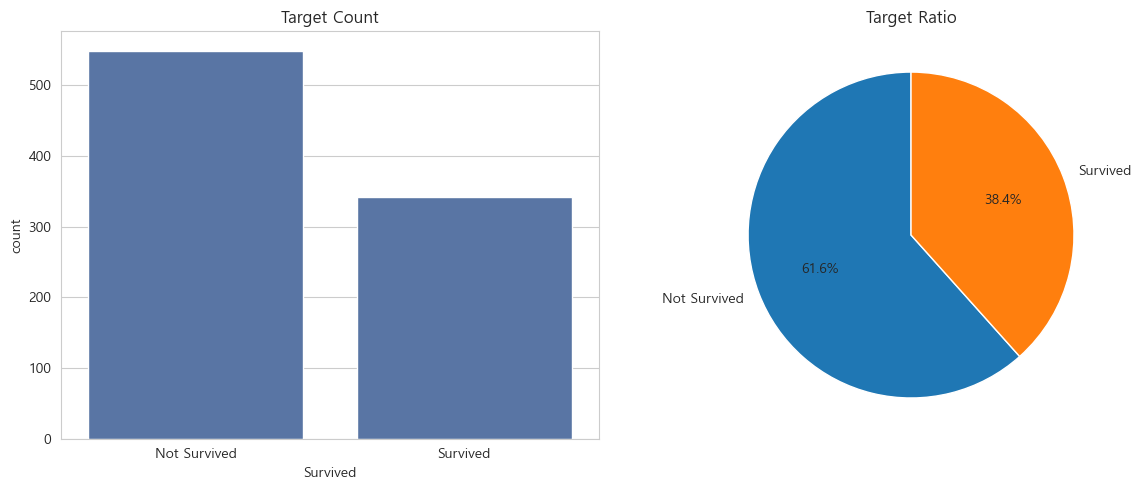

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x="Survived", data=df, ax=axes[0], color="#4C72B0")
axes[0].set_title("Target Count")
axes[0].set_xticklabels(["Not Survived", "Survived"])

survival_rate = df["Survived"].value_counts(normalize=True).sort_index()
axes[1].pie(
    survival_rate,
    labels=["Not Survived", "Survived"],
    autopct="%1.1f%%",
    startangle=90,
)
axes[1].set_title("Target Ratio")

plt.tight_layout()
plt.show()

## 2-7. 숫자형 변수(Numerical Feature) 분석

Histogram으로 분포를 확인하고, 왜도와 첨도를 계산합니다.

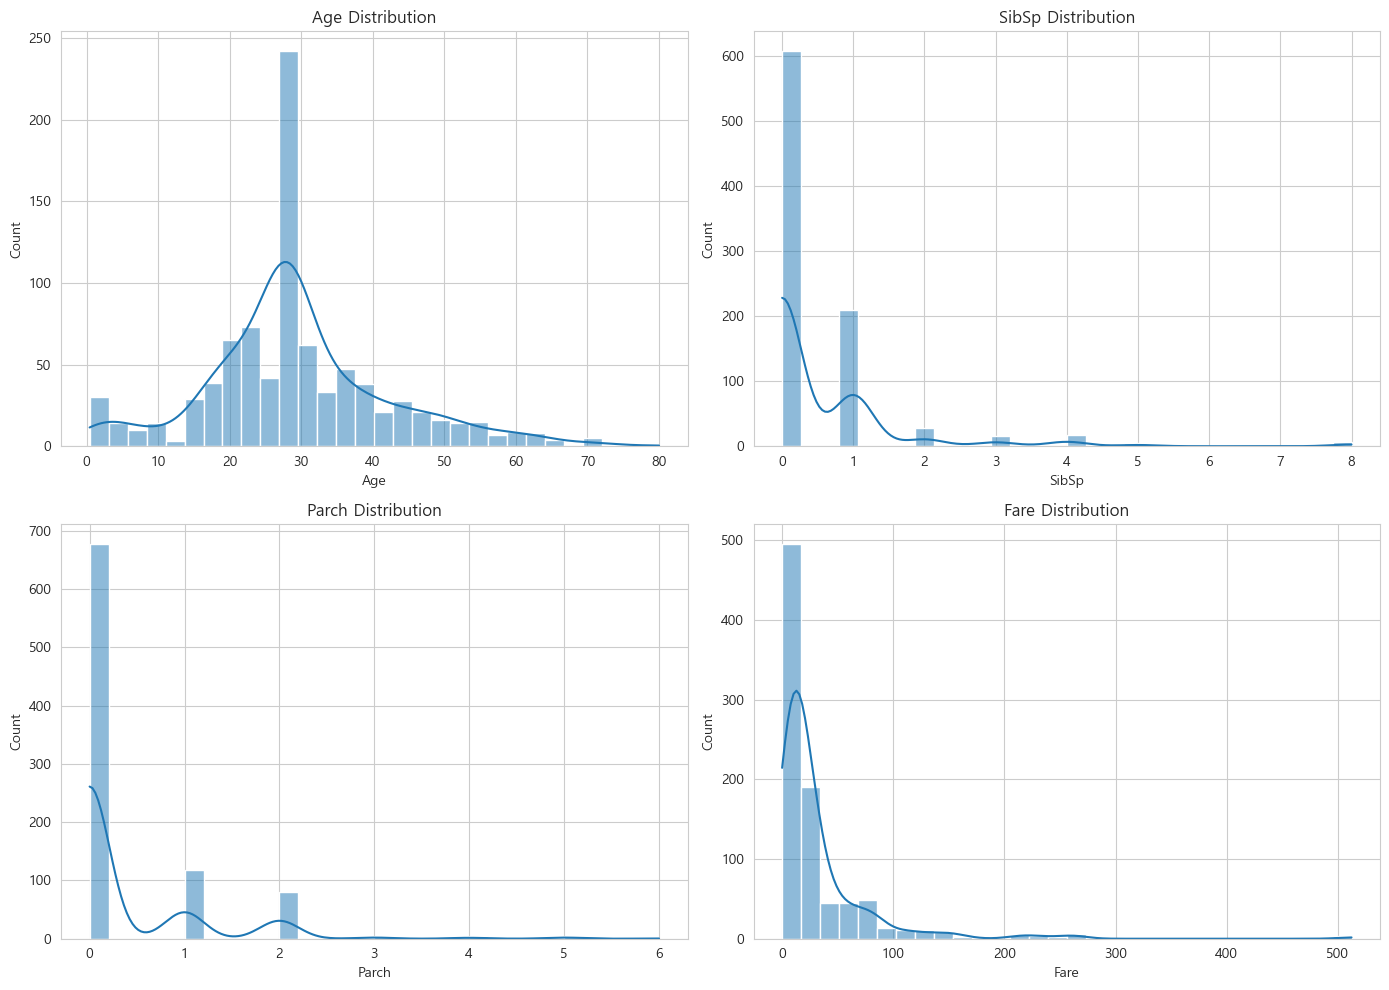

In [13]:
numeric_columns = ["Age", "SibSp", "Parch", "Fare"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")

plt.tight_layout()
plt.show()

In [14]:
skew_kurt = pd.DataFrame({
    "mean": df[numeric_columns].mean(),
    "std": df[numeric_columns].std(),
    "skew": df[numeric_columns].skew(),
    "kurtosis": df[numeric_columns].kurtosis(),
}).round(3)

display(skew_kurt)

,mean,std,skew,kurtosis
Age,29.362,13.020,0.510,0.994
SibSp,0.523,1.103,3.695,17.880
Parch,0.382,0.806,2.749,9.778
Fare,32.204,49.693,4.787,33.398


## 2-8. 범주형 변수(Categorical Feature) 분석

`Sex`, `Pclass`, `Embarked`별 승객 수와 생존률을 확인합니다.

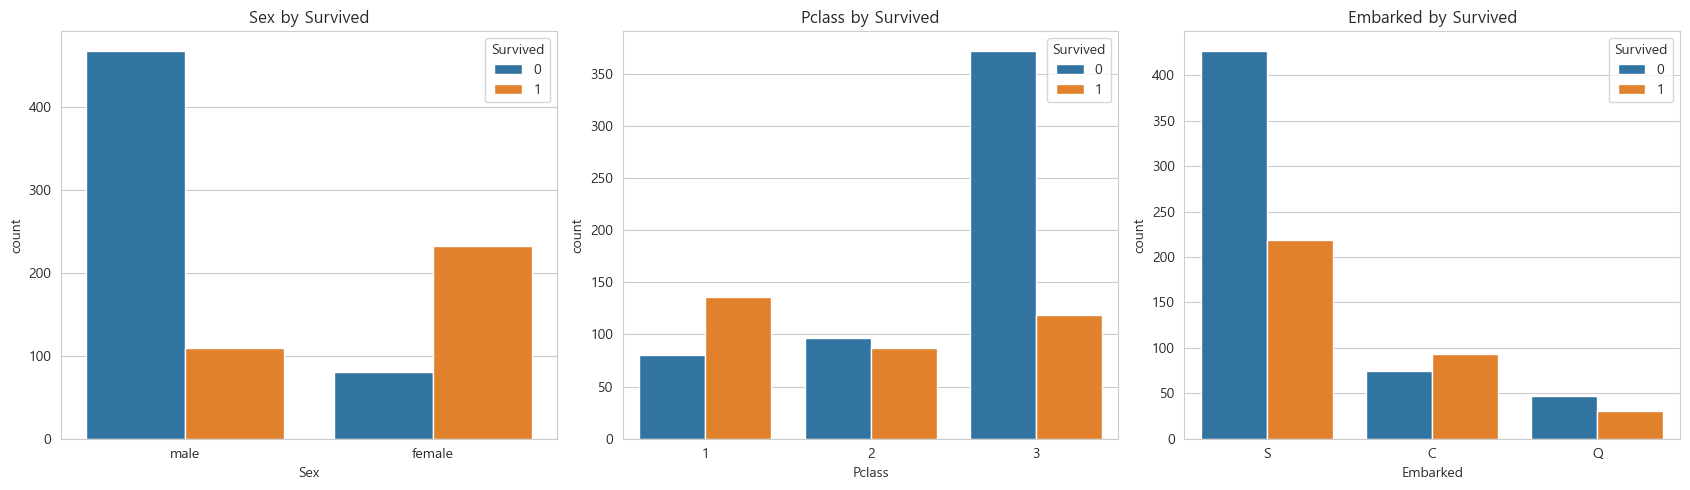

In [15]:
categorical_columns = ["Sex", "Pclass", "Embarked"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for i, col in enumerate(categorical_columns):
    sns.countplot(x=col, hue="Survived", data=df, ax=axes[i])
    axes[i].set_title(f"{col} by Survived")

plt.tight_layout()
plt.show()

In [16]:
for col in categorical_columns:
    print(f"--- {col}별 생존률 ---")
    result = df.groupby(col, dropna=False)["Survived"].agg(["mean", "count"])
    result["mean"] = (result["mean"] * 100).round(2)
    result = result.rename(columns={"mean": "survival_rate(%)"})
    display(result)

--- Sex별 생존률 ---


,survival_rate(%),count
Sex,,
female,74.20,314
male,18.89,577


--- Pclass별 생존률 ---


,survival_rate(%),count
Pclass,,
1,62.96,216
2,47.28,184
3,24.24,491


--- Embarked별 생존률 ---


,survival_rate(%),count
Embarked,,
C,55.36,168
Q,38.96,77
S,33.90,646


## 2-9. 나이(Age)와 생존 관계

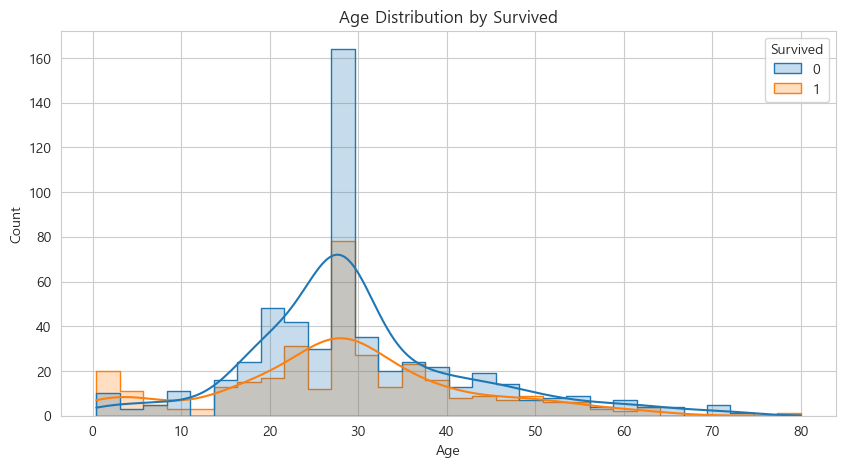

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True,
    element="step",
)
plt.title("Age Distribution by Survived")
plt.show()

## 2-10. 상관관계(Correlation) 분석

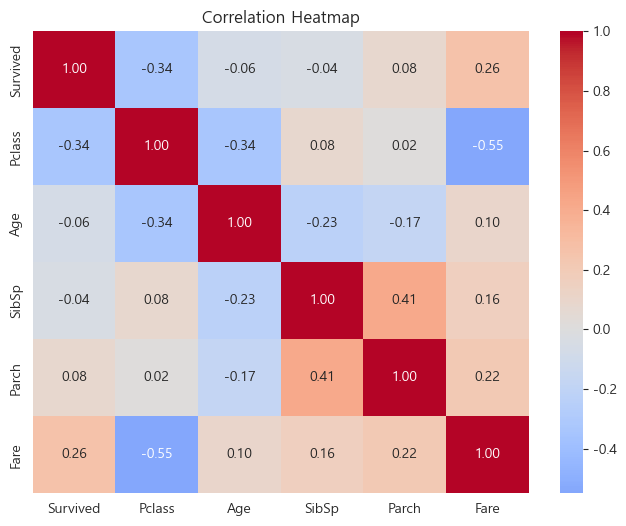

In [18]:
corr_columns = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
corr_matrix = df[corr_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## 2-11. Box Plot - 이상치(Outlier) 분석

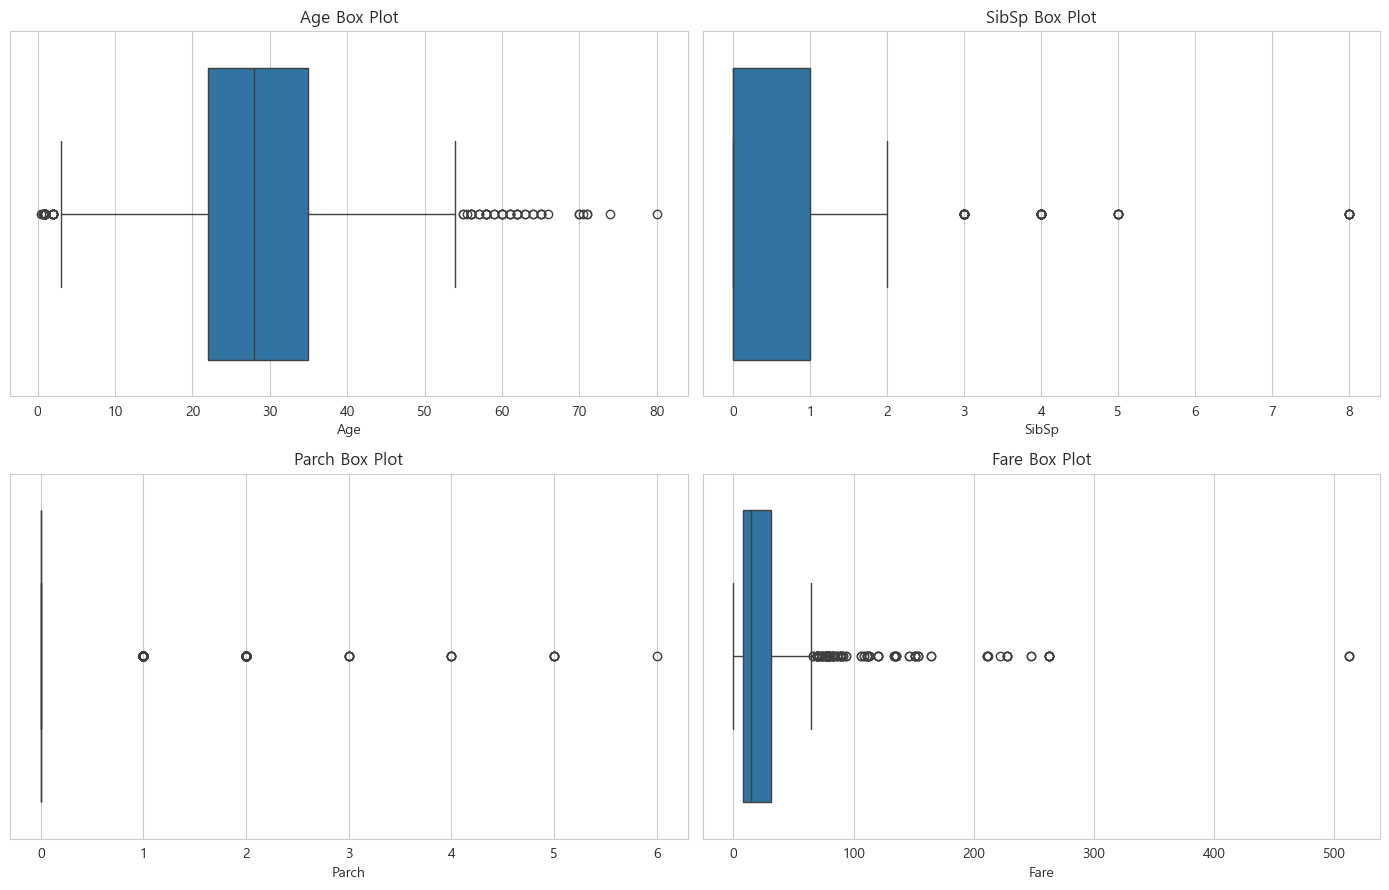

,outlier_count
Age,66
SibSp,46
Parch,213
Fare,116


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

outlier_summary = {}
for i, col in enumerate(numeric_columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"{col} Box Plot")

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_summary[col] = ((df[col] < lower) | (df[col] > upper)).sum()

plt.tight_layout()
plt.show()

display(pd.Series(outlier_summary, name="outlier_count").to_frame())

## 2-12. EDA 핵심 발견 사항(EDA Findings)

**Finding 1. 성별에 따라 생존률 차이가 크다.**  
여성의 생존률이 남성보다 높게 나타나는지 그룹 분석으로 확인합니다.

**Finding 2. 객실 등급(Pclass)이 높을수록 생존률이 높다.**  
1등실 승객은 2·3등실 승객보다 구조 접근성이 좋았을 가능성이 있습니다.

**Finding 3. Age와 Cabin에는 결측치가 존재한다.**  
Age는 중앙값 또는 그룹별 중앙값으로 대체하고, Cabin은 객실 정보 존재 여부로 변환할 수 있습니다.

**Finding 4. 가족 구성은 생존과 관련될 수 있다.**  
`SibSp`와 `Parch`를 합쳐 `FamilySize`, `IsAlone`을 만들 필요가 있습니다.


# Chapter 3. Hypothesis (가설 수립)

**가설 1.** 여성의 생존률은 남성보다 높을 것이다.  
**가설 2.** 1등실 승객의 생존률은 2·3등실 승객보다 높을 것이다.  
**가설 3.** 어린 승객은 성인 승객보다 생존률이 높을 것이다.  
**가설 4.** 혼자 탑승한 승객과 가족 동반 승객의 생존률은 다를 것이다.  
**가설 5.** 높은 운임을 지불한 승객은 생존률이 높을 것이다.  
**가설 6.** 이름에서 추출한 호칭(Title)은 성별·연령·사회적 지위를 함께 반영할 것이다.  
**가설 7.** 객실(Cabin) 정보가 존재하는 승객은 생존률이 높을 것이다.

# Chapter 4. Feature Engineering (파생변수 생성)

이번 Chapter에서는 다음 파생변수를 생성합니다.
1. `Title`
2. `FamilySize`
3. `IsAlone`
4. `AgeGroup`
5. `FarePerPerson`
6. `FareGroup`
7. `HasCabin`
8. `TicketGroupSize`

각 Feature를 추가할 때 간단한 분류 모델로 성능 변화를 확인합니다.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

BASELINE_COLUMNS = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
feature_experiment_results = []

RANDOM_STATE = 42

def quick_evaluate(frame, feature_cols, label):
    X = frame[feature_cols].copy()
    y = frame["Survived"]

    categorical = [c for c in feature_cols if str(X[c].dtype) in ["object", "category", "string"]]
    numerical = [c for c in feature_cols if c not in categorical]

    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numerical),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical),
    ])

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)
    proba = pipeline.predict_proba(X_test)[:, 1]

    return {
        "Experiment": label,
        "FeatureCount": len(feature_cols),
        "Accuracy": accuracy_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, proba),
    }

baseline_result = quick_evaluate(df, BASELINE_COLUMNS, "Baseline")
feature_experiment_results.append(baseline_result)
display(pd.DataFrame(feature_experiment_results).round(4))

,Experiment,FeatureCount,Accuracy,F1,ROC_AUC
0,Baseline,7,0.8045,0.7244,0.8445


## Feature 1. Title (이름에서 호칭 추출)


`Name`에는 `Mr`, `Mrs`, `Miss`, `Master` 등의 호칭이 포함되어 있습니다. 호칭은 성별, 연령대, 결혼 여부, 사회적 지위를 압축해서 보여주는 정보가 될 수 있습니다.

In [21]:
df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()

rare_titles = [
    "Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev",
    "Sir", "Jonkheer", "Dona"
]
df["Title"] = df["Title"].replace(rare_titles, "Rare")
df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

title_effect = df.groupby("Title")["Survived"].agg(["mean", "count"]).sort_values("mean", ascending=False)
title_effect["mean"] = (title_effect["mean"] * 100).round(2)
display(title_effect.rename(columns={"mean": "survival_rate(%)"}))

,survival_rate(%),count
Title,,
the Countess,100.00,1
Mrs,79.37,126
Miss,70.27,185
Master,57.50,40
Rare,31.82,22
Mr,15.67,517


In [22]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["Title"], "Title (이름에서 호칭 추출)")
feature_experiment_results.append(result)
display(pd.DataFrame(feature_experiment_results).round(4))

,Experiment,FeatureCount,Accuracy,F1,ROC_AUC
0,Baseline,7,0.8045,0.7244,0.8445
1,Title (이름에서 호칭 추출),8,0.8380,0.7786,0.8796


## Feature 2. FamilySize (가족 규모)


`SibSp`와 `Parch`에 승객 본인 1명을 더해 함께 탑승한 가족 규모를 만듭니다.

In [23]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

family_effect = df.groupby("FamilySize")["Survived"].agg(["mean", "count"])
family_effect["mean"] = (family_effect["mean"] * 100).round(2)
display(family_effect.rename(columns={"mean": "survival_rate(%)"}))

,survival_rate(%),count
FamilySize,,
1,30.35,537
2,55.28,161
3,57.84,102
4,72.41,29
5,20.00,15
6,13.64,22
7,33.33,12
8,0.00,6
11,0.00,7


In [24]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["Title", "FamilySize"], "FamilySize (가족 규모)")
feature_experiment_results.append(result)
display(pd.DataFrame(feature_experiment_results).round(4))

,Experiment,FeatureCount,Accuracy,F1,ROC_AUC
0,Baseline,7,0.8045,0.7244,0.8445
1,Title (이름에서 호칭 추출),8,0.8380,0.7786,0.8796
2,FamilySize (가족 규모),9,0.8380,0.7786,0.8796


## Feature 3. IsAlone (혼자 탑승 여부)


`FamilySize == 1`이면 혼자 탑승한 승객으로 표시합니다.

In [25]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

alone_effect = df.groupby("IsAlone")["Survived"].agg(["mean", "count"])
alone_effect["mean"] = (alone_effect["mean"] * 100).round(2)
display(alone_effect.rename(columns={"mean": "survival_rate(%)"}))

,survival_rate(%),count
IsAlone,,
0,50.56,354
1,30.35,537


In [26]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["Title", "FamilySize", "IsAlone"], "IsAlone (혼자 탑승 여부)")
feature_experiment_results.append(result)
display(pd.DataFrame(feature_experiment_results).round(4))

,Experiment,FeatureCount,Accuracy,F1,ROC_AUC
0,Baseline,7,0.8045,0.7244,0.8445
1,Title (이름에서 호칭 추출),8,0.8380,0.7786,0.8796
2,FamilySize (가족 규모),9,0.8380,0.7786,0.8796
3,IsAlone (혼자 탑승 여부),10,0.8547,0.8030,0.8804


## Feature 4. AgeGroup (나이 구간)


나이를 어린이, 청소년, 청년, 중년, 노년 구간으로 나눕니다. 결측치는 Title별 중앙값으로 먼저 보완합니다.

In [27]:
age_median_by_title = df.groupby("Title")["Age"].transform("median")
df["AgeFilled"] = df["Age"].fillna(age_median_by_title).fillna(df["Age"].median())

df["AgeGroup"] = pd.cut(
    df["AgeFilled"],
    bins=[0, 12, 18, 35, 60, np.inf],
    labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"],
    include_lowest=True,
)

age_group_effect = df.groupby("AgeGroup", observed=False)["Survived"].agg(["mean", "count"])
age_group_effect["mean"] = (age_group_effect["mean"] * 100).round(2)
display(age_group_effect.rename(columns={"mean": "survival_rate(%)"}))

,survival_rate(%),count
AgeGroup,,
Child,57.97,69
Teen,42.86,70
YoungAdult,35.33,535
Adult,40.00,195
Senior,22.73,22


In [28]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["Title", "FamilySize", "IsAlone", "AgeGroup"], "AgeGroup (나이 구간)")
feature_experiment_results.append(result)
display(pd.DataFrame(feature_experiment_results).round(4))

,Experiment,FeatureCount,Accuracy,F1,ROC_AUC
0,Baseline,7,0.8045,0.7244,0.8445
1,Title (이름에서 호칭 추출),8,0.8380,0.7786,0.8796
2,FamilySize (가족 규모),9,0.8380,0.7786,0.8796
3,IsAlone (혼자 탑승 여부),10,0.8547,0.8030,0.8804
4,AgeGroup (나이 구간),11,0.8492,0.7939,0.8806


## Feature 5. FarePerPerson (1인당 운임)


같은 Ticket을 공유한 그룹은 총 운임을 함께 지불했을 수 있으므로, 운임을 가족 규모로 나누어 1인당 운임을 만듭니다.

In [29]:
df["FarePerPerson"] = df["Fare"] / df["FamilySize"].replace(0, 1)
display(df[["Fare", "FamilySize", "FarePerPerson"]].head())

,Fare,FamilySize,FarePerPerson
0,7.2500,2,3.62500
1,71.2833,2,35.64165
2,7.9250,1,7.92500
3,53.1000,2,26.55000
4,8.0500,1,8.05000


In [30]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["Title", "FamilySize", "IsAlone", "AgeGroup", "FarePerPerson"], "FarePerPerson (1인당 운임)")
feature_experiment_results.append(result)
display(pd.DataFrame(feature_experiment_results).round(4))

,Experiment,FeatureCount,Accuracy,F1,ROC_AUC
0,Baseline,7,0.8045,0.7244,0.8445
1,Title (이름에서 호칭 추출),8,0.8380,0.7786,0.8796
2,FamilySize (가족 규모),9,0.8380,0.7786,0.8796
3,IsAlone (혼자 탑승 여부),10,0.8547,0.8030,0.8804
4,AgeGroup (나이 구간),11,0.8492,0.7939,0.8806
5,FarePerPerson (1인당 운임),12,0.8492,0.7939,0.8802


## Feature 6. FareGroup (운임 구간)


운임 분포가 오른쪽으로 치우쳐 있으므로 동일한 인원 수를 기준으로 4개 구간으로 나눕니다.

In [31]:
df["FareGroup"] = pd.qcut(df["Fare"], q=4, labels=["Low", "MidLow", "MidHigh", "High"], duplicates="drop")

fare_group_effect = df.groupby("FareGroup", observed=False)["Survived"].agg(["mean", "count"])
fare_group_effect["mean"] = (fare_group_effect["mean"] * 100).round(2)
display(fare_group_effect.rename(columns={"mean": "survival_rate(%)"}))

,survival_rate(%),count
FareGroup,,
Low,19.73,223
MidLow,30.36,224
MidHigh,45.50,222
High,58.11,222


In [32]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["Title", "FamilySize", "IsAlone", "AgeGroup", "FarePerPerson", "FareGroup"], "FareGroup (운임 구간)")
feature_experiment_results.append(result)
display(pd.DataFrame(feature_experiment_results).round(4))

,Experiment,FeatureCount,Accuracy,F1,ROC_AUC
0,Baseline,7,0.8045,0.7244,0.8445
1,Title (이름에서 호칭 추출),8,0.8380,0.7786,0.8796
2,FamilySize (가족 규모),9,0.8380,0.7786,0.8796
3,IsAlone (혼자 탑승 여부),10,0.8547,0.8030,0.8804
4,AgeGroup (나이 구간),11,0.8492,0.7939,0.8806
5,FarePerPerson (1인당 운임),12,0.8492,0.7939,0.8802
6,FareGroup (운임 구간),13,0.8492,0.7939,0.8746


## Feature Engineering 실험 종합

파생변수를 하나씩 누적하면서 Logistic Regression의 성능 변화를 확인했습니다. 성능이 항상 증가하지는 않습니다. 모델 종류와 데이터 분할에 따라 파생변수의 효과가 달라질 수 있으므로, 최종 판단은 Feature Selection과 여러 모델 비교 결과를 함께 사용해야 합니다.

,Experiment,FeatureCount,Accuracy,F1,ROC_AUC
0,Baseline,7,0.8045,0.7244,0.8445
1,Title (이름에서 호칭 추출),8,0.8380,0.7786,0.8796
2,FamilySize (가족 규모),9,0.8380,0.7786,0.8796
3,IsAlone (혼자 탑승 여부),10,0.8547,0.8030,0.8804
4,AgeGroup (나이 구간),11,0.8492,0.7939,0.8806
5,FarePerPerson (1인당 운임),12,0.8492,0.7939,0.8802
6,FareGroup (운임 구간),13,0.8492,0.7939,0.8746


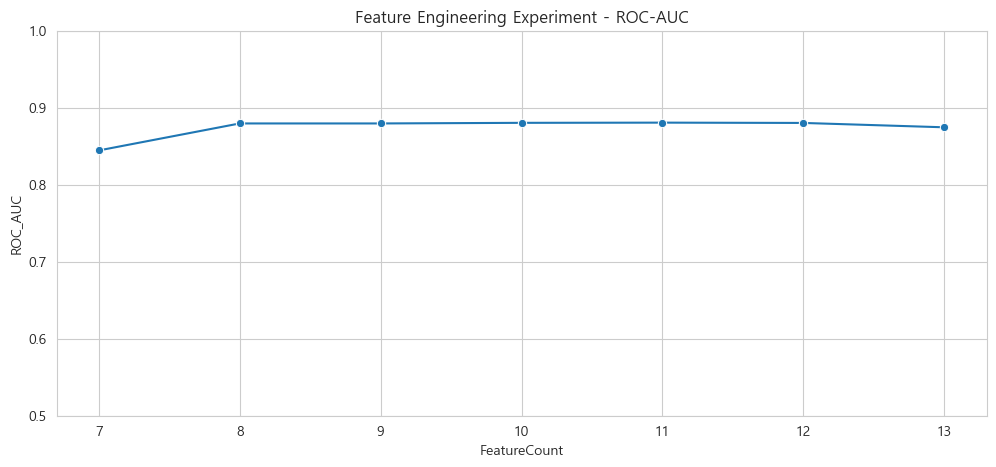

In [33]:
feature_experiment_df = pd.DataFrame(feature_experiment_results)
display(feature_experiment_df.round(4))

plt.figure(figsize=(12, 5))
sns.lineplot(data=feature_experiment_df, x="FeatureCount", y="ROC_AUC", marker="o")
plt.title("Feature Engineering Experiment - ROC-AUC")
plt.ylim(0.5, 1.0)
plt.show()

# Chapter 5. Feature Selection (5단계 축소판)

- 분산이 없는 Feature 확인
- 준상수 Feature 확인
- 상관관계가 높은 Feature 확인
- RandomForest Feature Importance 확인
- 최종 Feature 목록 결정

In [34]:
ENGINEERED_COLUMNS = [
    "Title", "FamilySize", "IsAlone", "AgeFilled", "AgeGroup",
    "FarePerPerson", "FareGroup", "HasCabin", "TicketGroupSize",
]

ALL_FEATURE_COLUMNS = [
    "Pclass", "Sex", "AgeFilled", "SibSp", "Parch", "Fare", "Embarked",
    "Title", "FamilySize", "IsAlone", "AgeGroup", "FarePerPerson",
    "FareGroup",
]

X_fs = df[ALL_FEATURE_COLUMNS].copy()
y_fs = df["Survived"].copy()
print("Feature Selection 입력 Shape:", X_fs.shape)

Feature Selection 입력 Shape: (891, 13)


## Step 1. Variance Threshold

In [35]:
from sklearn.feature_selection import VarianceThreshold

numeric_fs = X_fs.select_dtypes(include=np.number).fillna(0)
variance_selector = VarianceThreshold(threshold=0.0)
variance_selector.fit(numeric_fs)
zero_variance_columns = numeric_fs.columns[~variance_selector.get_support()].tolist()
print("분산이 0인 숫자형 Feature:", zero_variance_columns)

분산이 0인 숫자형 Feature: []


## Step 2. Quasi Constant Feature (준상수 Feature)

In [36]:
def find_quasi_constant_columns(X, dominant_ratio=0.95):
    result = []
    for col in X.columns:
        top_ratio = X[col].value_counts(dropna=False, normalize=True).iloc[0]
        if top_ratio >= dominant_ratio:
            result.append((col, round(top_ratio, 4)))
    return result

quasi_constant_columns = find_quasi_constant_columns(X_fs, dominant_ratio=0.95)
print("준상수 Feature:", quasi_constant_columns)

준상수 Feature: []


## Step 3. Correlation Analysis (상관관계 분석)

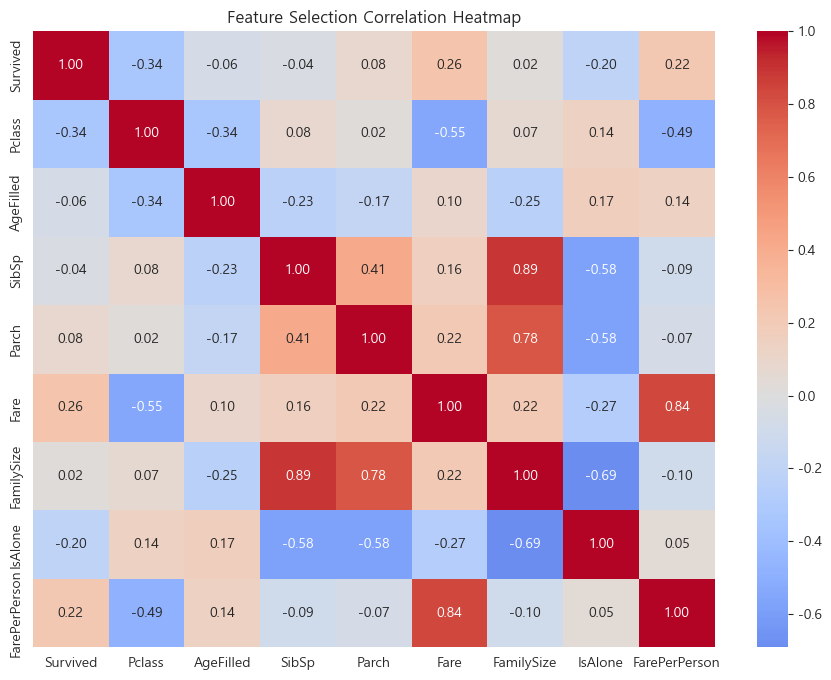

In [37]:
corr_numeric_columns = [
    "Survived", "Pclass", "AgeFilled", "SibSp", "Parch", "Fare",
    "FamilySize", "IsAlone", "FarePerPerson", 
]
fs_corr_matrix = df[corr_numeric_columns].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(fs_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Selection Correlation Heatmap")
plt.show()

In [38]:
def find_highly_correlated_pairs(corr_matrix, threshold=0.80):
    pairs = []
    columns = corr_matrix.columns
    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            value = corr_matrix.iloc[i, j]
            if abs(value) >= threshold:
                pairs.append((columns[i], columns[j], round(value, 4)))
    return pairs

high_corr_pairs = find_highly_correlated_pairs(fs_corr_matrix.drop(index="Survived", columns="Survived"), 0.80)
print("상관계수 절댓값 0.80 이상 Feature 쌍:")
for pair in high_corr_pairs:
    print(pair)

상관계수 절댓값 0.80 이상 Feature 쌍:
('SibSp', 'FamilySize', np.float64(0.8907))
('Fare', 'FarePerPerson', np.float64(0.841))


## Step 4. RandomForest Feature Importance

In [39]:
from sklearn.ensemble import RandomForestClassifier

categorical_fs = [c for c in ALL_FEATURE_COLUMNS if str(X_fs[c].dtype) in ["object", "category", "string"]]
numerical_fs = [c for c in ALL_FEATURE_COLUMNS if c not in categorical_fs]

fs_preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numerical_fs),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_fs),
])

X_fs_processed = fs_preprocessor.fit_transform(X_fs)
feature_names = fs_preprocessor.get_feature_names_out()

rf_selector = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced",
)
rf_selector.fit(X_fs_processed, y_fs)

rf_importance = pd.Series(rf_selector.feature_importances_, index=feature_names).sort_values(ascending=False)
display(rf_importance.head(20).to_frame("importance"))

,importance
num__AgeFilled,0.167109
num__FarePerPerson,0.135702
num__Fare,0.130857
cat__Title_Mr,0.105712
cat__Sex_male,0.089030
cat__Sex_female,0.067178
num__Pclass,0.048335
num__FamilySize,0.040037
num__SibSp,0.024406
cat__Title_Miss,0.023175


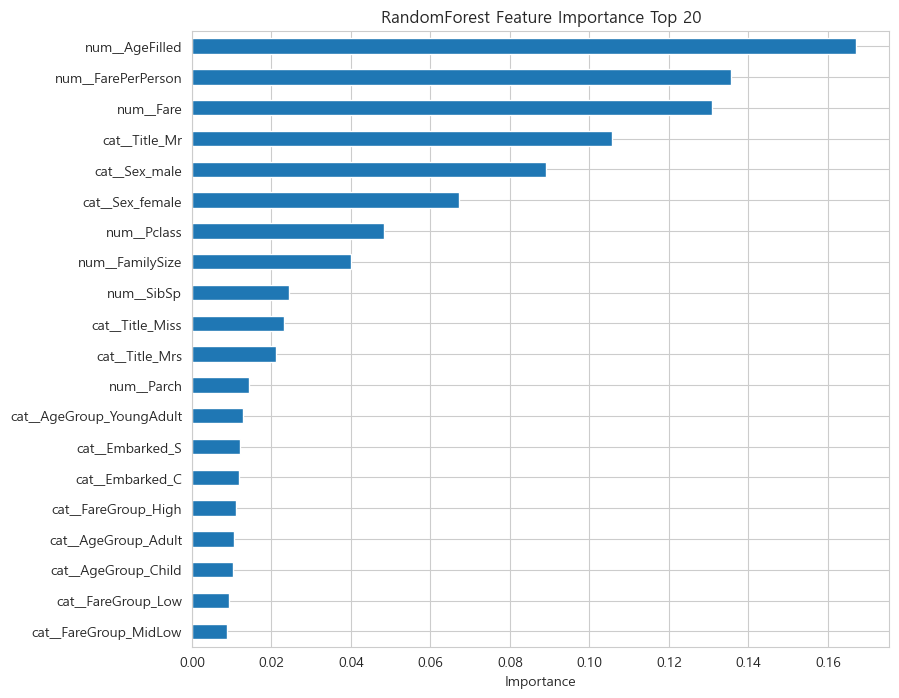

In [40]:
plt.figure(figsize=(9, 8))
rf_importance.head(20).sort_values().plot(kind="barh")
plt.title("RandomForest Feature Importance Top 20")
plt.xlabel("Importance")
plt.show()

## Step 5. Final Feature Selection Report

In [41]:
# PassengerId는 단순 식별자이며, Name/Ticket/Cabin 원문은 고유값이 많아 직접 사용하지 않습니다.
# Age 대신 결측치를 보완한 AgeFilled를 사용합니다.
# FamilySize가 SibSp와 Parch의 정보를 통합하므로, 최종 목록에서는 원본 두 컬럼을 제외할 수 있습니다.

FINAL_FEATURE_COLUMNS = [
    "Pclass",
    "Sex",
    "AgeFilled",
    "Fare",
    "Embarked",
    "Title",
    "FamilySize",
    "IsAlone",
    "AgeGroup",
    "FarePerPerson",
    "FareGroup",
]

print("최종 Feature 수:", len(FINAL_FEATURE_COLUMNS))
print(FINAL_FEATURE_COLUMNS)

최종 Feature 수: 11
['Pclass', 'Sex', 'AgeFilled', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'FarePerPerson', 'FareGroup']


# Chapter 6. Model Comparison

Titanic은 분류 문제이므로 다음 지표를 비교합니다.
- Accuracy: 전체 예측 중 정답 비율
- Precision: 생존으로 예측한 승객 중 실제 생존 비율
- Recall: 실제 생존자를 찾아낸 비율
- F1: Precision과 Recall의 조화평균
- ROC-AUC: 임계값 전반의 분류 능력

In [42]:
X = df[FINAL_FEATURE_COLUMNS].copy()
y = df["Survived"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

categorical_features = [c for c in FINAL_FEATURE_COLUMNS if str(X[c].dtype) in ["object", "category", "string"]]
numeric_features = [c for c in FINAL_FEATURE_COLUMNS if c not in categorical_features]

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)
print("숫자형 Feature:", numeric_features)
print("범주형 Feature:", categorical_features)

Train Shape: (712, 11)
Test Shape: (179, 11)
숫자형 Feature: ['Pclass', 'AgeFilled', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson']
범주형 Feature: ['Sex', 'Embarked', 'Title', 'AgeGroup', 'FareGroup']


In [43]:
preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])


## 6-1. 4가지 모델 소개

| 모델 | 학습 방식 | 역할 |
|---|---|---|
| Logistic Regression | 생존 확률을 선형 결합과 시그모이드 함수로 계산 | 해석하기 쉬운 Baseline |
| Decision Tree | 조건을 반복하여 데이터를 분할 | 규칙 기반 모델 이해 |
| Random Forest | 여러 Decision Tree의 결과를 결합 | 안정적인 앙상블 |
| XGBoost | 이전 트리의 오류를 다음 트리가 보완 | 고성능 부스팅 |

In [44]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)

def evaluate_pipeline(
    pipeline,
    model_name,
    X_train,
    y_train,
    X_test,
    y_test,
):
    # 모델 학습
    pipeline.fit(X_train, y_train)

    # 클래스 예측
    pred = pipeline.predict(X_test)

    # 생존 확률 예측
    proba = pipeline.predict_proba(X_test)[:, 1]

    # 평가 결과
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, proba),
    }

    print(f"=== {model_name} ===")

    # 문자열인 Model을 제외하고 숫자 데이터만 출력
    metric_values = {
        key: value
        for key, value in metrics.items()
        if key != "Model"
    }

    print(pd.Series(metric_values, dtype="float64").round(4))

    print("\nClassification Report")
    print(
        classification_report(
            y_test,
            pred,
            target_names=["Not Survived", "Survived"],
            zero_division=0,
        )
    )

    return metrics, pred, proba, pipeline    

model_comparison_results = []
fitted_pipelines = {}
model_predictions = {}
model_probabilities = {}


## 6-2. Logistic Regression

In [45]:
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

logreg_metrics, logreg_pred, logreg_proba, logreg_pipeline = evaluate_pipeline(
    logreg_pipeline, "Logistic Regression", X_train, y_train, X_test, y_test
)

model_comparison_results.append(logreg_metrics)
fitted_pipelines["Logistic Regression"] = logreg_pipeline
model_predictions["Logistic Regression"] = logreg_pred
model_probabilities["Logistic Regression"] = logreg_proba

=== Logistic Regression ===
Accuracy     0.8492
Precision    0.8387
Recall       0.7536
F1           0.7939
ROC_AUC      0.8723
dtype: float64

Classification Report
              precision    recall  f1-score   support

Not Survived       0.85      0.91      0.88       110
    Survived       0.84      0.75      0.79        69

    accuracy                           0.85       179
   macro avg       0.85      0.83      0.84       179
weighted avg       0.85      0.85      0.85       179



## 6-3. Decision Tree

In [46]:
from sklearn.tree import DecisionTreeClassifier

tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE, class_weight="balanced")),
])

tree_metrics, tree_pred, tree_proba, tree_pipeline = evaluate_pipeline(
    tree_pipeline, "Decision Tree", X_train, y_train, X_test, y_test
)

model_comparison_results.append(tree_metrics)
fitted_pipelines["Decision Tree"] = tree_pipeline
model_predictions["Decision Tree"] = tree_pred
model_probabilities["Decision Tree"] = tree_proba

=== Decision Tree ===
Accuracy     0.7933
Precision    0.7051
Recall       0.7971
F1           0.7483
ROC_AUC      0.8487
dtype: float64

Classification Report
              precision    recall  f1-score   support

Not Survived       0.86      0.79      0.82       110
    Survived       0.71      0.80      0.75        69

    accuracy                           0.79       179
   macro avg       0.78      0.79      0.79       179
weighted avg       0.80      0.79      0.80       179



## 6-4. Random Forest

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced",
    )),
])

rf_metrics, rf_pred, rf_proba, rf_pipeline = evaluate_pipeline(
    rf_pipeline, "Random Forest", X_train, y_train, X_test, y_test
)

model_comparison_results.append(rf_metrics)
fitted_pipelines["Random Forest"] = rf_pipeline
model_predictions["Random Forest"] = rf_pred
model_probabilities["Random Forest"] = rf_proba

=== Random Forest ===
Accuracy     0.8156
Precision    0.7727
Recall       0.7391
F1           0.7556
ROC_AUC      0.8258
dtype: float64

Classification Report
              precision    recall  f1-score   support

Not Survived       0.84      0.86      0.85       110
    Survived       0.77      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



## 6-5. XGBoost

In [48]:
# 설치되지 않았다면 아래 셀을 먼저 실행하세요.
# %pip install xgboost

In [49]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

xgb_metrics, xgb_pred, xgb_proba, xgb_pipeline = evaluate_pipeline(
    xgb_pipeline, "XGBoost", X_train, y_train, X_test, y_test
)

model_comparison_results.append(xgb_metrics)
fitted_pipelines["XGBoost"] = xgb_pipeline
model_predictions["XGBoost"] = xgb_pred
model_probabilities["XGBoost"] = xgb_proba

=== XGBoost ===
Accuracy     0.8268
Precision    0.8065
Recall       0.7246
F1           0.7634
ROC_AUC      0.8387
dtype: float64

Classification Report
              precision    recall  f1-score   support

Not Survived       0.84      0.89      0.86       110
    Survived       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



## 6-6. 4개 모델 종합 비교

In [50]:
model_comparison_df = pd.DataFrame(model_comparison_results)
model_comparison_df = model_comparison_df.sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
display(model_comparison_df.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.8492,0.8387,0.7536,0.7939,0.8723
1,Decision Tree,0.7933,0.7051,0.7971,0.7483,0.8487
2,XGBoost,0.8268,0.8065,0.7246,0.7634,0.8387
3,Random Forest,0.8156,0.7727,0.7391,0.7556,0.8258


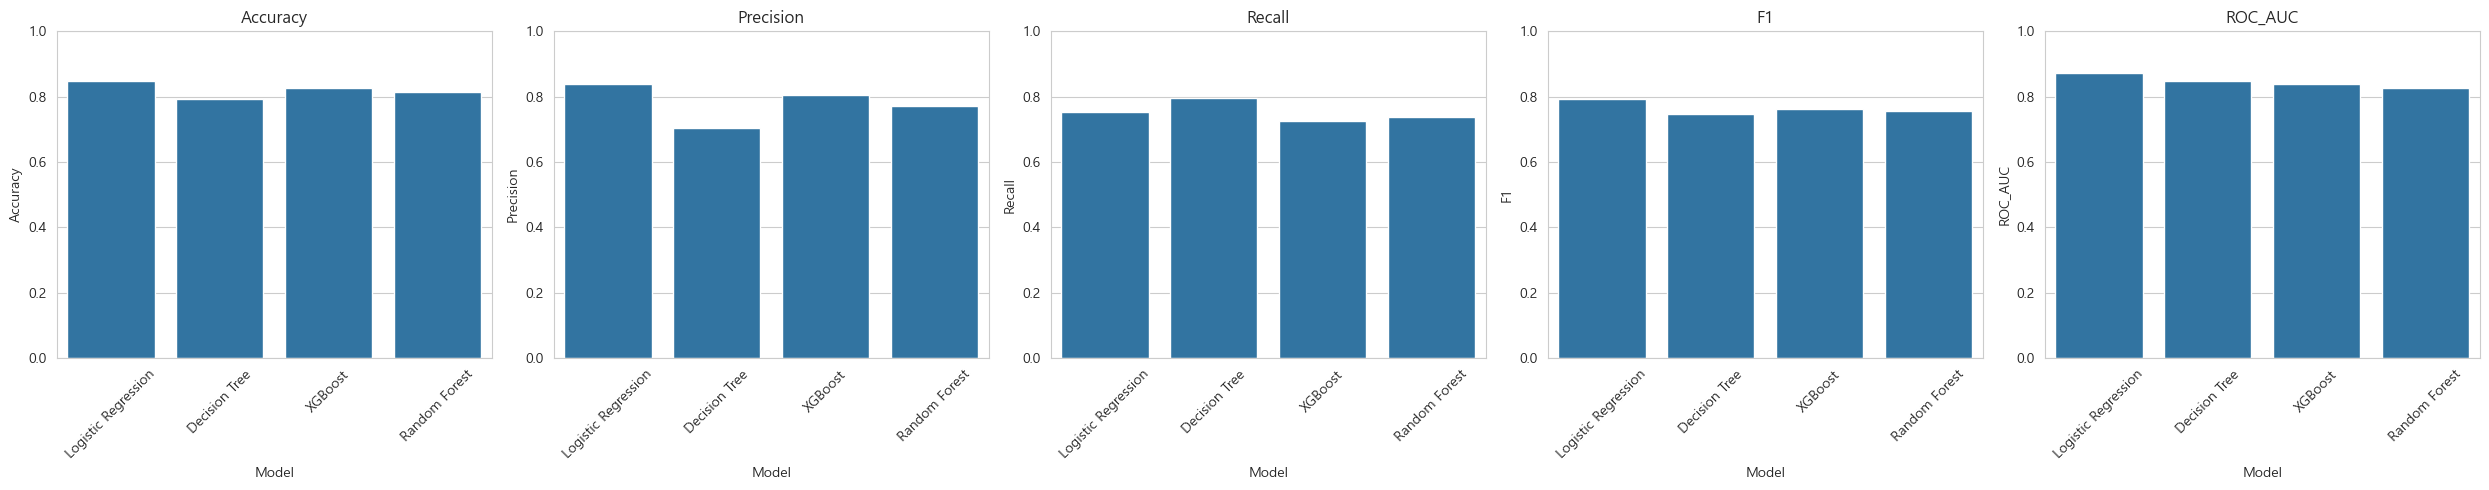

In [51]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x="Model", y=metric, data=model_comparison_df, ax=axes[i])
    axes[i].set_title(metric)
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## ROC Curve 비교

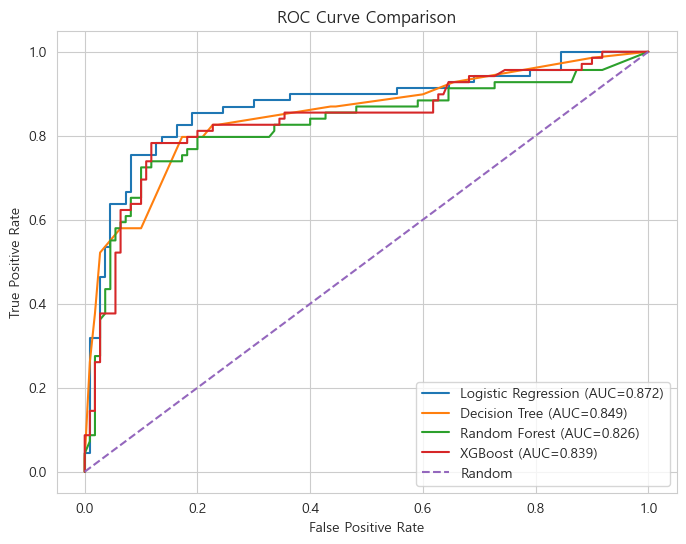

In [52]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))
for name, proba in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Chapter 7. Final Model (최종 모델)

이 프로젝트에서는 **ROC-AUC를 우선 기준**으로 최종 모델을 선정합니다. 클래스 분포와 임계값에 덜 의존하면서 생존자와 사망자를 구분하는 전반적인 능력을 평가할 수 있기 때문입니다. 실제 서비스 목적에 따라 Recall 또는 F1을 우선할 수도 있습니다.

In [53]:
print("=== Chapter 6 모델 비교 결과 ===")
display(model_comparison_df.round(4))

best_auc_row = model_comparison_df.loc[model_comparison_df["ROC_AUC"].idxmax()]
print("\nROC-AUC 기준 최고 성능:")
print(best_auc_row)


=== Chapter 6 모델 비교 결과 ===


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.8492,0.8387,0.7536,0.7939,0.8723
1,Decision Tree,0.7933,0.7051,0.7971,0.7483,0.8487
2,XGBoost,0.8268,0.8065,0.7246,0.7634,0.8387
3,Random Forest,0.8156,0.7727,0.7391,0.7556,0.8258



ROC-AUC 기준 최고 성능:
Model        Logistic Regression
Accuracy                0.849162
Precision                0.83871
Recall                  0.753623
F1                      0.793893
ROC_AUC                 0.872332
Name: 0, dtype: object


### 자세한 비교 해석

1. **Accuracy**는 전체 승객을 얼마나 정확히 분류했는지 보여줍니다.  
2. **Precision**은 생존으로 예측한 승객 중 실제 생존자의 비율입니다.  
3. **Recall**은 실제 생존자를 얼마나 놓치지 않고 찾았는지 보여줍니다.  
4. **F1**은 Precision과 Recall의 균형을 평가합니다.  
5. **ROC-AUC**는 여러 임계값에서 두 클래스를 구분하는 능력을 종합적으로 평가합니다.

In [54]:
FINAL_MODEL_NAME = best_auc_row["Model"]
final_pipeline = fitted_pipelines[FINAL_MODEL_NAME]

print(f"최종 선정 모델: {FINAL_MODEL_NAME}")

최종 선정 모델: Logistic Regression


### 💥 최종 모델 저장 - 향후 서비스 진행 시 실행

In [56]:
!pip install joblib

In [58]:
import joblib

MODEL_SAVE_DIR = "../models"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
MODEL_SAVE_PATH = os.path.join(MODEL_SAVE_DIR, "titanic_survival_pipeline.pkl")

joblib.dump(final_pipeline, MODEL_SAVE_PATH)
print("모델 저장 완료:", MODEL_SAVE_PATH)

NameError: name 'os' is not defined

# Chapter 8. Research Report (연구 보고서)

지금까지의 분석 과정과 최종 결과를 Markdown 보고서로 자동 생성합니다.

In [ ]:
from IPython.display import Markdown, display

final_row = model_comparison_df[model_comparison_df["Model"] == FINAL_MODEL_NAME].iloc[0]

report = f"""
# Titanic Survival AI Research Report

## 1. 프로젝트 목적
승객의 객실 등급, 성별, 나이, 운임, 가족관계 등의 정보를 이용하여 생존 여부를 예측하는 이진 분류 모델을 개발했다.

## 2. 데이터 개요
- 데이터 크기: {df.shape[0]:,}행 × {df.shape[1]}열
- Target: Survived (0=사망, 1=생존)
- 생존률: {df['Survived'].mean() * 100:.2f}%

## 3. 주요 EDA 결과
- 성별에 따라 생존률 차이가 크게 나타났다.
- 객실 등급이 높을수록 생존률이 높은 경향이 나타났다.
- Age와 Cabin에 결측치가 존재했다.
- Fare는 오른쪽으로 치우치고 이상치가 많았다.
- 가족 규모와 혼자 탑승 여부가 생존과 관련될 가능성이 확인되었다.

## 4. Feature Engineering
- Title
- FamilySize
- IsAlone
- AgeGroup
- FarePerPerson
- FareGroup
- HasCabin
- TicketGroupSize

## 5. 비교 모델
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

## 6. 최종 모델
- 모델: {FINAL_MODEL_NAME}
- Accuracy: {final_row['Accuracy']:.4f}
- Precision: {final_row['Precision']:.4f}
- Recall: {final_row['Recall']:.4f}
- F1: {final_row['F1']:.4f}
- ROC-AUC: {final_row['ROC_AUC']:.4f}

## 7. 결론
ROC-AUC를 우선 기준으로 최종 모델을 선정했다. 실제 서비스에서는 생존자를 놓치지 않는 것이 중요하면 Recall을, 생존 예측의 신뢰성이 중요하면 Precision을 추가로 고려해야 한다.
"""

display(Markdown(report))


# Titanic Survival AI Research Report

## 1. 프로젝트 목적
승객의 객실 등급, 성별, 나이, 운임, 가족관계 등의 정보를 이용하여 생존 여부를 예측하는 이진 분류 모델을 개발했다.

## 2. 데이터 개요
- 데이터 크기: 891행 × 19열
- Target: Survived (0=사망, 1=생존)
- 생존률: 38.38%

## 3. 주요 EDA 결과
- 성별에 따라 생존률 차이가 크게 나타났다.
- 객실 등급이 높을수록 생존률이 높은 경향이 나타났다.
- Age와 Cabin에 결측치가 존재했다.
- Fare는 오른쪽으로 치우치고 이상치가 많았다.
- 가족 규모와 혼자 탑승 여부가 생존과 관련될 가능성이 확인되었다.

## 4. Feature Engineering
- Title
- FamilySize
- IsAlone
- AgeGroup
- FarePerPerson
- FareGroup
- HasCabin
- TicketGroupSize

## 5. 비교 모델
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

## 6. 최종 모델
- 모델: Logistic Regression
- Accuracy: 0.8492
- Precision: 0.8387
- Recall: 0.7536
- F1: 0.7939
- ROC-AUC: 0.8723

## 7. 결론
ROC-AUC를 우선 기준으로 최종 모델을 선정했다. 실제 서비스에서는 생존자를 놓치지 않는 것이 중요하면 Recall을, 생존 예측의 신뢰성이 중요하면 Precision을 추가로 고려해야 한다.
